In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

BIOEMU_DIVERSITY_DIR = '../data/diversity'

In [23]:
def diversity(matrix: np.ndarray) -> tuple[float, float, float]:
    """
    take matrix, remove diagonal, and return mean, variance, std of upper triangle values 
    """

    if matrix.shape[0] != matrix.shape[1]:
        raise ValueError("Input matrix must be square.")
    
    n = matrix.shape[0]
    if n < 2:
        raise ValueError("Input matrix must have at least 2 rows/columns.")
    
    # Get upper triangle indices, excluding the diagonal
    upper_tri_indices = np.triu_indices(n, k=1)
    
    # Extract upper triangle values
    upper_tri_values = matrix[upper_tri_indices]
    
    # Calculate and return the mean, variance, and standard deviation of the upper triangle values
    return np.mean(upper_tri_values), np.var(upper_tri_values), np.std(upper_tri_values), np.max(upper_tri_values) - np.min(upper_tri_values), np.argmax(upper_tri_values), np.argmin(upper_tri_values)

High diversity for 1m1z: Range = 32.32 Å, Max = (23, 25), Min = (21, 5). Structures MAX: frame_00023.pdb, frame_00025.pdb with RMSD = 33.94 Å. Structures MIN: frame_00021.pdb, frame_00005.pdb with RMSD = 2.57 Å.
High diversity for 6irx: Range = 40.50 Å, Max = (7, 11), Min = (2, 15). Structures MAX: frame_00007.pdb, frame_00011.pdb with RMSD = 42.48 Å. Structures MIN: frame_00002.pdb, frame_00015.pdb with RMSD = 39.49 Å.
High diversity for 6owy: Range = 31.60 Å, Max = (11, 43), Min = (27, 5). Structures MAX: frame_00011.pdb, frame_00043.pdb with RMSD = 32.27 Å. Structures MIN: frame_00027.pdb, frame_00005.pdb with RMSD = 1.26 Å.
High diversity for 2phz: Range = 40.92 Å, Max = (8, 20), Min = (3, 13). Structures MAX: frame_00008.pdb, frame_00020.pdb with RMSD = 42.45 Å. Structures MIN: frame_00003.pdb, frame_00013.pdb with RMSD = 2.08 Å.
High diversity for 8evv: Range = 32.27 Å, Max = (34, 39), Min = (14, 20). Structures MAX: frame_00034.pdb, frame_00039.pdb with RMSD = 33.32 Å. Structure

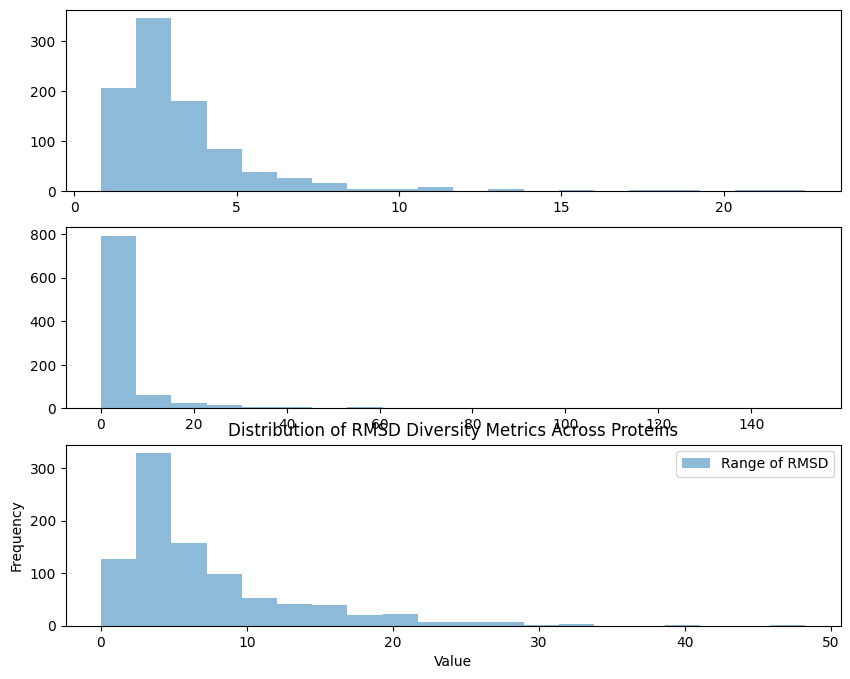

In [27]:
means, variances, stds, range_vals = [], [], [], []

for path in os.listdir(BIOEMU_DIVERSITY_DIR):
    if path.endswith('.csv'):
        protein_id = path.split('.')[0]
        # print(f"Processing {protein_id}...")
        rmsd_df = pd.read_csv(os.path.join(BIOEMU_DIVERSITY_DIR, path), index_col=0)

        mean, var, std, range_val, argmax_val, argmin_val = diversity(rmsd_df.values)
        means.append(mean)
        variances.append(var)
        stds.append(std)
        range_vals.append(range_val)

        max_val_index = np.unravel_index(np.argmax(rmsd_df.values, axis=None), rmsd_df.values.shape)
        min_val_index = np.unravel_index(np.argmin(rmsd_df.values[rmsd_df.values > 0], axis=None), rmsd_df.values.shape)

        if range_val > 30:
            print(f"High diversity for {protein_id}: Range = {range_val:.2f} Å, Max = {max_val_index}, Min = {min_val_index}. Structures MAX: {rmsd_df.index[max_val_index[0]]}, {rmsd_df.columns[max_val_index[1]]} with RMSD = {rmsd_df.values[max_val_index]:.2f} Å. Structures MIN: {rmsd_df.index[min_val_index[0]]}, {rmsd_df.columns[min_val_index[1]]} with RMSD = {rmsd_df.values[min_val_index]:.2f} Å.")

        

plt.figure(figsize=(10, 8))
plt.subplot(3, 1, 1)
plt.hist(means, bins=20, alpha=0.5, label='Mean RMSD')
plt.subplot(3, 1, 2)
plt.hist(variances, bins=20, alpha=0.5, label='Variance of RMSD')
plt.subplot(3, 1, 3)
plt.hist(range_vals, bins=20, alpha=0.5, label='Range of RMSD')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Distribution of RMSD Diversity Metrics Across Proteins')
plt.legend()
plt.show()
